# Multiple Choice Question Evaluation for Zeolite Synthesis

**Llama-3-8B-Instruct Evaluation**

This notebook evaluates LLM performance on multiple-choice questions about zeolite synthesis.

**Model:**
- Llama-3-8B-Instruct (GPU 3)

**Configuration:**
- k=10
- 7 retrieval methods: Abstract baseline, No context, FAISS, MMR, BM25, Hybrid, LLM-Optimized

**Structure:**
- Phase 1: Abstract, No Context, FAISS (with intermediate results plot)
- Phase 2: MMR, BM25, Hybrid, LLM-Optimized (with full results plot)

Run with kernel v6 instead of v7

In [1]:
# Core imports
import os
import torch
import json
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import gc

# LangChain (for retrieval only) and Transformers
from langchain.prompts import ChatPromptTemplate
from langchain.llms import HuggingFacePipeline
from langchain.chains import LLMChain
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig, pipeline

# Load HuggingFace token
!source /home/jupyter/Mrigi/env.sh
hf_token = os.environ.get("HF_TOKEN")

In [2]:
!nvidia-smi

Mon Feb 23 12:54:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.119.02             Driver Version: 580.119.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               Off |   00000000:31:00.0 Off |                  Off |
| 30%   39C    P8             21W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!kill -9 107001

/bin/bash: line 0: kill: (107001) - No such process


In [4]:
# Model Configuration
MODELS = {
    'llama': {
        'name': 'meta-llama/Meta-Llama-3-8B-Instruct',
        'display_name': 'Llama-3-8B-Instruct',
        'gpu': 'cuda:3'
    }
}

K_VALUES = [10]
METHODS = ['abstract', 'no_context', 'faiss', 'mmr', 'bm25', 'hybrid', 'optimized']

def load_model(model_key):
    """
    Load a model on a specific GPU.
    
    Args:
        model_key: Key from MODELS dictionary
    
    Returns:
        tuple: (llm, model, tokenizer) - LangChain LLM and underlying components
    """
    config = MODELS[model_key]
    model_name = config['name']
    device = config['gpu']
    
    print(f"\n{'='*80}")
    print(f"Loading {config['display_name']} on {device}...")
    print(f"{'='*80}")
    
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True,
        use_fast=True,
        token=hf_token
    )
    
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map=device,
        trust_remote_code=True,
        torch_dtype=torch.float16,
        token=hf_token
    )
    
    # Set up generation config
    generation_config = GenerationConfig.from_pretrained(model_name)
    generation_config.max_new_tokens = 100
    generation_config.temperature = 0.1
    
    # Set up pipeline
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        generation_config=generation_config,
    )
    llm = HuggingFacePipeline(pipeline=pipe)
    
    print(f"✓ {config['display_name']} loaded successfully on {device}")
    print(f"  max_new_tokens=100, temperature=0.1, use_fast=True")
    
    return llm, model, tokenizer

def cleanup_model(model, tokenizer):
    """Clean up model from GPU memory."""
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print("✓ GPU memory cleared")

print("✓ Model management functions defined")

✓ Model management functions defined


In [5]:
# Multiple choice prompt template
MC_PROMPT = """
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. You may use the provided context to inform your answer as well as your own knowledge. 

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E.
Context:
{context}

Question: {question}
"""

In [6]:
def extract_completion(full_response, tokenizer):
    """
    Extract the assistant's completion from the full response using Llama special tokens.
    Splits on the assistant header tag to isolate just the model's output.
    """
    assistant_tag = "<|start_header_id|>assistant<|end_header_id|>"
    if assistant_tag in full_response:
        completion = full_response.split(assistant_tag)[-1].strip()
    else:
        completion = full_response.strip()
    
    # Remove any end-of-text tokens
    for token in ["<|eot_id|>", "<|end_of_text|>"]:
        completion = completion.replace(token, "").strip()
    
    return completion

def parse_mc_answer(completion):
    """
    Parse a multiple choice answer from the model's completion.
    Uses rfind to get the last 'Answer: ' occurrence (avoids matching the example).
    """
    last_answer_pos = completion.rfind("Answer: ")
    
    if last_answer_pos != -1:
        model_answer = completion[last_answer_pos + 8].upper()
        
        if model_answer in ['A', 'B', 'C', 'D', 'E']:
            explanation = ""
            answer_end = completion[last_answer_pos:].split('\n')[0]
            if '-' in answer_end:
                explanation = answer_end.split('-', 1)[1].strip()
            return model_answer, explanation
    
    return None, None

def evaluate_mc_response(llm, query, correct_answer, context, tokenizer):
    """Evaluate a single multiple choice question with context."""
    prompt_text = MC_PROMPT.format(context=context, question=query)
    
    # Apply Llama chat template with user role
    messages = [{"role": "user", "content": prompt_text}]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    try:
        # Get model's answer using direct call
        full_response = llm(formatted_prompt)
        
        # Extract assistant completion using special tokens
        completion = extract_completion(full_response, tokenizer)
        
        # Parse the answer
        model_answer, explanation = parse_mc_answer(completion)
        
        if model_answer is not None:
            return {
                'query': query,
                'context': context,
                'model_answer': model_answer,
                'correct_answer': correct_answer,
                'is_correct': model_answer == correct_answer,
                'full_response': completion,
                'explanation': explanation or ""
            }
        
        # No valid answer found
        return {
            'query': query,
            'context': context,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'full_response': completion,
            'error': "No valid answer found in response"
        }
        
    except Exception as e:
        print(f"Processing error: {str(e)}")
        return {
            'query': query,
            'context': context,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"Error processing response: {str(e)}"
        }

def evaluate_mc_no_context(llm, query, correct_answer, tokenizer):
    """Evaluate a single multiple choice question WITHOUT context."""
    NO_CONTEXT_PROMPT = """You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer.

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E.

Question: {question}"""
    
    prompt_text = NO_CONTEXT_PROMPT.format(question=query)
    
    # Apply Llama chat template with user role
    messages = [{"role": "user", "content": prompt_text}]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    try:
        # Get model's answer using direct call
        full_response = llm(formatted_prompt)
        
        # Extract assistant completion using special tokens
        completion = extract_completion(full_response, tokenizer)
        
        # Parse the answer
        model_answer, explanation = parse_mc_answer(completion)
        
        if model_answer is not None:
            return {
                'query': query,
                'model_answer': model_answer,
                'correct_answer': correct_answer,
                'is_correct': model_answer == correct_answer,
                'full_response': completion,
                'explanation': explanation or ""
            }
        
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'full_response': completion,
            'error': "No valid answer found in response"
        }
        
    except Exception as e:
        print(f"Processing error: {str(e)}")
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"Error processing response: {str(e)}"
        }

print("✓ Evaluation functions defined (with chat template + special token parsing)")

✓ Evaluation functions defined (with chat template + special token parsing)


In [7]:
def get_faiss_context(query, k=10):
    """Retrieve context using FAISS similarity search."""
    results = vector_db.similarity_search(query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

def get_mmr_context(query, k=10):
    """Retrieve context using Maximum Marginal Relevance."""
    results = vector_db.max_marginal_relevance_search(query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

def get_bm25_context(query, k=10):
    """Retrieve context using BM25 retriever."""
    results = bm25_retriever.get_relevant_documents(query)[:k]
    return "\n\n".join([doc.page_content for doc in results])

def get_hybrid_context(query, k=10):
    """Retrieve context using hybrid (ensemble) retriever."""
    results = ensemble_retriever.get_relevant_documents(query)[:k]
    return "\n\n".join([doc.page_content for doc in results])

def get_optimized_context(query, llm, tokenizer, k=10):
    """Retrieve context using LLM-optimized retrieval."""
    # Apply chat template for the optimization prompt
    prompt_text = OPTIMIZE_QUERY_PROMPT.format(question=query)
    messages = [{"role": "user", "content": prompt_text}]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    # Get optimized query
    full_response = llm(formatted_prompt)
    optimized_query = extract_completion(full_response, tokenizer)
    
    # Clean up - take only first line
    optimized_query = optimized_query.split('\n')[0].strip()
    
    # Use optimized query for retrieval
    results = vector_db.similarity_search(optimized_query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

# Unified evaluation function for all methods
def evaluate_method(llm, method_name, questions_df, tokenizer, k=10):
    """
    Evaluate a specific retrieval method.
    
    Args:
        llm: LangChain LLM instance
        method_name: Name of the method ('abstract', 'no_context', 'faiss', etc.)
        questions_df: DataFrame with questions
        tokenizer: Tokenizer for applying chat template
        k: Number of documents to retrieve
    
    Returns:
        dict: Results with accuracy and detailed responses
    """
    results = []
    
    for _, row in tqdm(questions_df.iterrows(), total=len(questions_df), 
                       desc=f"Evaluating {method_name} (k={k})"):
        query = row['Question']
        correct_answer = row['Correct_Answer']
        
        if method_name == 'abstract':
            context = row['Context']
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'no_context':
            result = evaluate_mc_no_context(llm, query, correct_answer, tokenizer)
        elif method_name == 'faiss':
            context = get_faiss_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'mmr':
            context = get_mmr_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'bm25':
            context = get_bm25_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'hybrid':
            context = get_hybrid_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'optimized':
            context = get_optimized_context(query, llm, tokenizer, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        else:
            raise ValueError(f"Unknown method: {method_name}")
        
        results.append(result)
    
    # Calculate accuracy
    correct_count = sum(1 for r in results if r.get('is_correct', False))
    total = len(results)
    accuracy = (correct_count / total) * 100 if total > 0 else 0
    
    return {
        'method': method_name,
        'k': k,
        'accuracy': accuracy,
        'correct_count': correct_count,
        'total': total,
        'detailed_results': results
    }

print("✓ Retrieval and unified evaluation functions defined")

✓ Retrieval and unified evaluation functions defined


In [8]:
# Load the vector database and retrieval components
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.vectorstores import FAISS
from langchain.retrievers import BM25Retriever
from pathlib import Path

# Initialize embeddings
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

# Load FAISS index
INDEX_DIRECTORY = Path("faiss_index")
INDEX_NAME = "index"

if not INDEX_DIRECTORY.exists():
    raise FileNotFoundError(f"Vector index directory '{INDEX_DIRECTORY}' not found.")

vector_db = FAISS.load_local(
    INDEX_DIRECTORY,
    embeddings,
    index_name=INDEX_NAME,
    allow_dangerous_deserialization=True
)
faiss_retriever = vector_db.as_retriever(search_kwargs={"k": 10})
print(f"\u2713 Loaded vector database from {INDEX_DIRECTORY} with {vector_db.index.ntotal} vectors")

# Get all documents for BM25
all_docs = vector_db.similarity_search("", k=vector_db.index.ntotal)
bm25_retriever = BM25Retriever.from_documents(all_docs)
bm25_retriever.k = 10
print(f"\u2713 Initialized BM25 retriever with {len(all_docs)} documents")

/tmp/ipykernel_2987699/2821454396.py:8: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")


/tmp/ipykernel_2987699/2821454396.py:8: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")


✓ Loaded vector database from faiss_index with 1474439 vectors
✓ Initialized BM25 retriever with 1474439 documents
✓ Initialized BM25 retriever with 1474439 documents


In [9]:
# Define hybrid search function
from langchain.retrievers import EnsembleRetriever

def hybrid_search(query, vector_db, bm25_retriever, k_total=10, k_bm25=10, k_mmr=10, 
                  mmr_fetch_k=40, mmr_lambda=0.6):
    """
    Hybrid retrieval combining BM25 and MMR results.
    """
    # Get BM25 results
    bm25_retriever.k = k_bm25
    bm25_docs = bm25_retriever.get_relevant_documents(query)
    
    # Get MMR results
    mmr_docs = vector_db.max_marginal_relevance_search(
        query,
        k=k_mmr,
        fetch_k=mmr_fetch_k,
        lambda_mult=mmr_lambda
    )
    
    # Combine and deduplicate
    seen_content = set()
    combined_docs = []
    
    for doc in bm25_docs + mmr_docs:
        content_hash = hash(doc.page_content)
        if content_hash not in seen_content:
            seen_content.add(content_hash)
            combined_docs.append(doc)
            if len(combined_docs) >= k_total:
                break
    
    return combined_docs

# Create ensemble retriever for hybrid method
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, faiss_retriever],
    weights=[0.5, 0.5]
)

print("\u2713 Hybrid search function and ensemble retriever defined")

✓ Hybrid search function and ensemble retriever defined


In [10]:
# Query optimizer prompt and function for LLM-optimized retrieval
OPTIMIZE_QUERY_PROMPT = """You are helping optimize multiple choice questions for academic literature search.
Given a multiple choice question about zeolite synthesis, extract the core scientific concepts and convert it into a concise keyword-based search query.
Focus on the main topic: materials, synthesis methods, characterization techniques, properties, or conditions being asked about.
Remove question phrasing, multiple choice options (A-E), and filler words.
Preserve chemical formulas, abbreviations, and domain-specific terminology.
Output a single line of lowercase keywords in a natural but compact order.
Do not explain or summarize—only output the optimized search query.

Question: {question}

Optimized query:"""

def optimize_query_for_mcq(question: str, llm, tokenizer) -> str:
    """
    Use LLM to convert a multiple choice question into an optimized search query.
    Uses chat template with special tokens for proper Llama formatting.
    """
    try:
        prompt_text = OPTIMIZE_QUERY_PROMPT.format(question=question)
        messages = [{"role": "user", "content": prompt_text}]
        formatted_prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        
        response = llm(formatted_prompt)
        completion = extract_completion(response, tokenizer)
        
        # Clean up - take only first line
        optimized_query = completion.split('\n')[0].strip()
        
        return optimized_query if optimized_query else question
    except Exception as e:
        print(f"Error optimizing query: {e}")
        return question

print("✓ Query optimizer prompt and function defined")

✓ Query optimizer prompt and function defined


In [11]:
# Load the question dataset
mc_questions_df = pd.read_excel('questionbank(unedited).xlsx', sheet_name='Synthesis')
mc_questions_df = mc_questions_df.dropna(subset=['gpt_generated_question'])
mc_questions_df = mc_questions_df.rename(columns={
    'gpt_generated_question': 'Question',
    'gpt_generated_answer': 'Correct_Answer',
    'abstract': 'Context'
})
mc_questions_df['Correct_Answer'] = mc_questions_df['Correct_Answer'].str.strip().str.upper()

print(f"\u2713 Loaded {len(mc_questions_df)} questions from question bank")
print(f"\u2713 Columns: {list(mc_questions_df.columns)}")

✓ Loaded 39 questions from question bank
✓ Columns: ['Context', 'Question', 'Correct_Answer', 'doi']


## Phase 1: Abstract, No Context, and FAISS

Run the first three methods and generate an intermediate results plot.

In [12]:
# Initialize results storage and load model
all_results = {}
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Load Llama model
llm, model, tokenizer = load_model('llama')
model_display_name = MODELS['llama']['display_name']
all_results[model_display_name] = {}

# Phase 1 methods
phase1_methods = ['abstract', 'no_context', 'faiss']

for k in K_VALUES:
    print(f"\n{'='*80}")
    print(f"Running Phase 1 experiments with k={k}")
    print(f"{'='*80}")
    
    all_results[model_display_name][f"k={k}"] = {}
    
    for method in phase1_methods:
        print(f"\n--- Evaluating {method.upper()} with k={k} on {model_display_name} ---")
        
        try:
            result = evaluate_method(llm, method, mc_questions_df, tokenizer, k=k)
            all_results[model_display_name][f"k={k}"][method] = result
            
            print(f"✓ {method.upper()}: {result['accuracy']:.2f}% "
                  f"({result['correct_count']}/{result['total']})")
            
            # Save intermediate results
            temp_save_path = f'results_llama_k10_intermediate_{timestamp}.json'
            with open(temp_save_path, 'w') as f:
                json.dump(all_results, f, indent=2)
            
        except Exception as e:
            print(f"✗ Error evaluating {method}: {str(e)}")
            all_results[model_display_name][f"k={k}"][method] = {
                'error': str(e),
                'accuracy': 0,
                'correct_count': 0,
                'total': 0
            }

print(f"\n{'='*80}")
print(f"Phase 1 complete!")
print(f"{'='*80}")


Loading Llama-3-8B-Instruct on cuda:3...



Loading Llama-3-8B-Instruct on cuda:3...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.



Loading Llama-3-8B-Instruct on cuda:3...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


...

✓ ABSTRACT: 100.00% (39/39)

--- Evaluating NO_CONTEXT with k=10 on Llama-3-8B-Instruct ---


Evaluating no_context (k=10):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order 

✓ NO_CONTEXT: 79.49% (31/39)

--- Evaluating FAISS with k=10 on Llama-3-8B-Instruct ---


Evaluating faiss (k=10):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to ma

✓ FAISS: 82.05% (32/39)

Phase 1 complete!



PHASE 1 RESULTS: Abstract, No Context, FAISS
Model                     K     Method          Accuracy     Correct/Total  
--------------------------------------------------------------------------------
Llama-3-8B-Instruct       10    abstract        100.00%      39/39
Llama-3-8B-Instruct       10    no_context       79.49%      31/39
Llama-3-8B-Instruct       10    faiss            82.05%      32/39


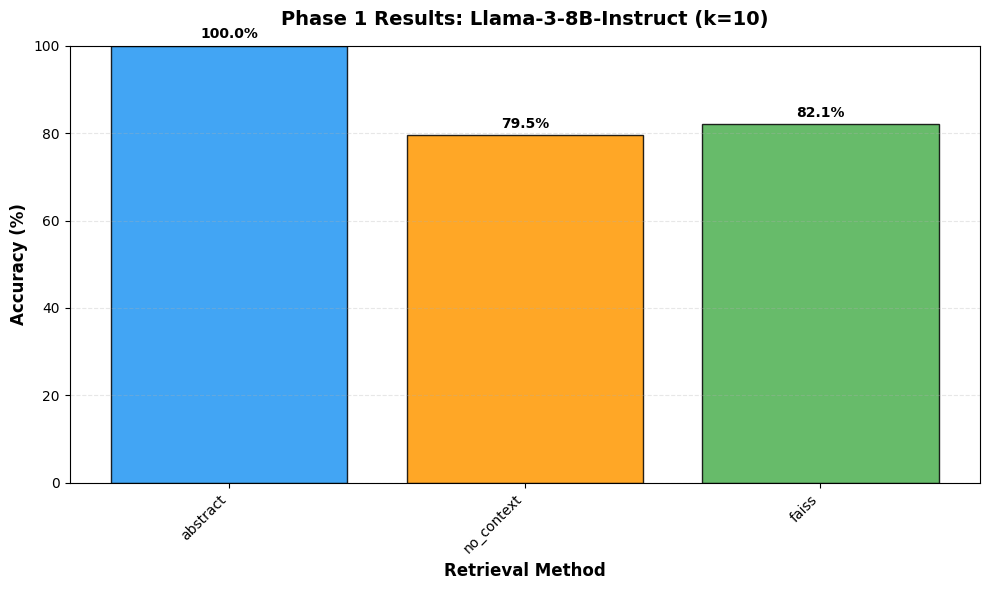

✓ Phase 1 bar chart generated


In [13]:
# Phase 1 Results: Bar chart for Abstract, No Context, FAISS
import matplotlib.pyplot as plt
import numpy as np

# Collect Phase 1 results
phase1_data = []
for model_name in all_results.keys():
    for k_label in all_results[model_name].keys():
        k_value = int(k_label.split('=')[1])
        for method in all_results[model_name][k_label].keys():
            result = all_results[model_name][k_label][method]
            phase1_data.append({
                'model': model_name,
                'k': k_value,
                'method': method,
                'accuracy': result.get('accuracy', 0),
                'correct': result.get('correct_count', 0),
                'total': result.get('total', 0)
            })

phase1_df = pd.DataFrame(phase1_data)

# Print summary table
print("\n" + "="*80)
print("PHASE 1 RESULTS: Abstract, No Context, FAISS")
print("="*80)
print(f"{'Model':<25} {'K':<5} {'Method':<15} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*80)
for _, row in phase1_df.iterrows():
    print(f"{row['model']:<25} {row['k']:<5} {row['method']:<15} "
          f"{row['accuracy']:>6.2f}%      {row['correct']}/{row['total']}")
print("="*80)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))

methods_phase1 = phase1_df['method'].unique()
x = np.arange(len(methods_phase1))
accuracies = [phase1_df[phase1_df['method'] == m]['accuracy'].values[0] for m in methods_phase1]

bars = ax.bar(x, accuracies, color=['#2196F3', '#FF9800', '#4CAF50'], alpha=0.85, edgecolor='black')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Retrieval Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Phase 1 Results: {model_display_name} (k={K_VALUES[0]})',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(methods_phase1, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\u2713 Phase 1 bar chart generated")

## Phase 2: MMR, BM25, Hybrid, LLM-Optimized

Run the remaining four retrieval methods.

In [14]:
# Phase 2 methods
phase2_methods = ['mmr', 'bm25', 'hybrid', 'optimized']

for k in K_VALUES:
    print(f"\n{'='*80}")
    print(f"Running Phase 2 experiments with k={k}")
    print(f"{'='*80}")
    
    for method in phase2_methods:
        print(f"\n--- Evaluating {method.upper()} with k={k} on {model_display_name} ---")
        
        try:
            result = evaluate_method(llm, method, mc_questions_df, tokenizer, k=k)
            all_results[model_display_name][f"k={k}"][method] = result
            
            print(f"✓ {method.upper()}: {result['accuracy']:.2f}% "
                  f"({result['correct_count']}/{result['total']})")
            
            # Save intermediate results
            temp_save_path = f'results_llama_k10_intermediate_{timestamp}.json'
            with open(temp_save_path, 'w') as f:
                json.dump(all_results, f, indent=2)
            
        except Exception as e:
            print(f"✗ Error evaluating {method}: {str(e)}")
            all_results[model_display_name][f"k={k}"][method] = {
                'error': str(e),
                'accuracy': 0,
                'correct_count': 0,
                'total': 0
            }

# Final save
final_save_path = f'results_llama_k10_final_{timestamp}.json'
with open(final_save_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\n{'='*80}")
print(f"Phase 2 complete! Results saved to: {final_save_path}")
print(f"{'='*80}")


Running Phase 2 experiments with k=10

--- Evaluating MMR with k=10 on Llama-3-8B-Instruct ---



Running Phase 2 experiments with k=10

--- Evaluating MMR with k=10 on Llama-3-8B-Instruct ---


Evaluating mmr (k=10):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maxi


Running Phase 2 experiments with k=10

--- Evaluating MMR with k=10 on Llama-3-8B-Instruct ---


Evaluating mmr (k=10):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maxi

...

✓ BM25: 84.62% (33/39)

--- Evaluating HYBRID with k=10 on Llama-3-8B-Instruct ---


Evaluating hybrid (k=10):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to m

✓ HYBRID: 87.18% (34/39)

--- Evaluating OPTIMIZED with k=10 on Llama-3-8B-Instruct ---


Evaluating optimized (k=10):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order t

✓ OPTIMIZED: 79.49% (31/39)

Phase 2 complete! Results saved to: results_llama_k10_final_20260223_125640.json


## Full Results: All Methods


FULL RESULTS: All Methods
Model                     K     Method          Accuracy     Correct/Total  
--------------------------------------------------------------------------------
Llama-3-8B-Instruct       10    abstract        100.00%      39/39
Llama-3-8B-Instruct       10    no_context       79.49%      31/39
Llama-3-8B-Instruct       10    faiss            82.05%      32/39
Llama-3-8B-Instruct       10    mmr              84.62%      33/39
Llama-3-8B-Instruct       10    bm25             84.62%      33/39
Llama-3-8B-Instruct       10    hybrid           87.18%      34/39
Llama-3-8B-Instruct       10    optimized        79.49%      31/39

✓ BEST: abstract - 100.00%
✗ WORST: no_context - 79.49%
Δ Range: 20.51%


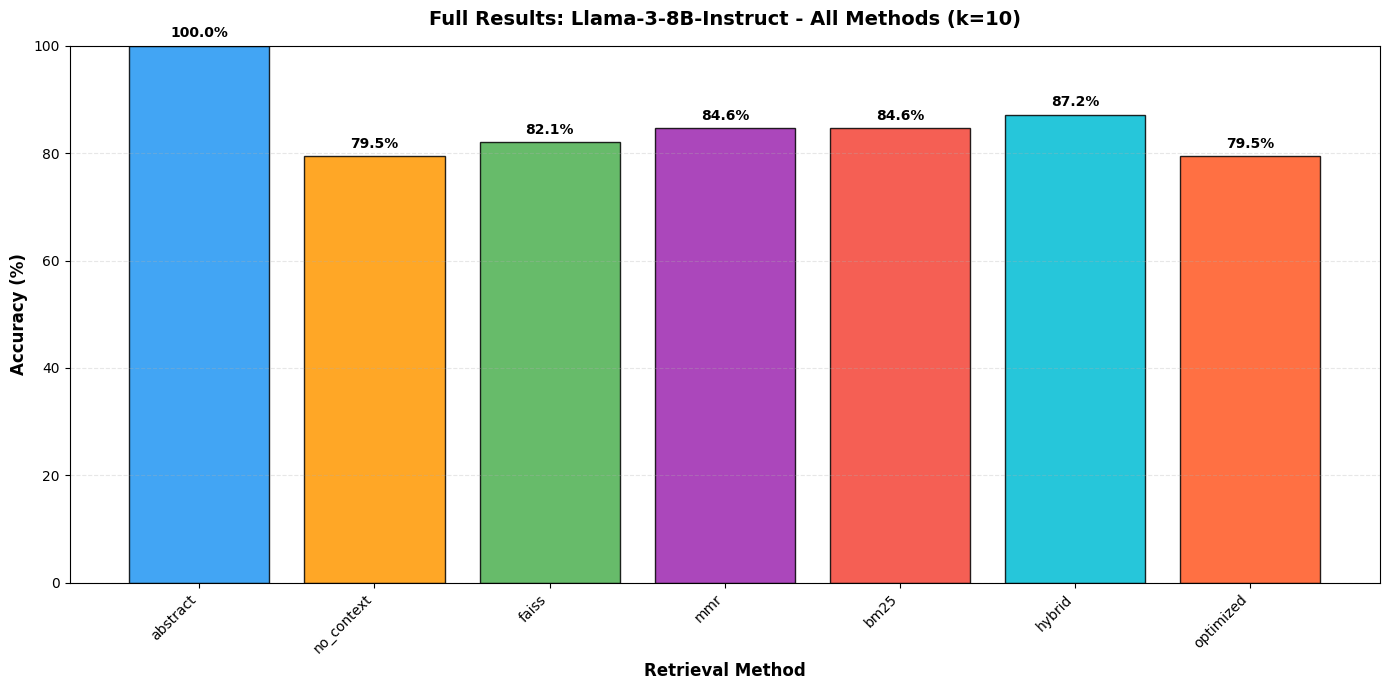

✓ Full results bar chart generated


In [15]:
# Full Results: Bar chart for all 7 methods
viz_data = []
for model_name in all_results.keys():
    for k_label in all_results[model_name].keys():
        k_value = int(k_label.split('=')[1])
        for method in all_results[model_name][k_label].keys():
            result = all_results[model_name][k_label][method]
            viz_data.append({
                'model': model_name,
                'k': k_value,
                'method': method,
                'accuracy': result.get('accuracy', 0),
                'correct': result.get('correct_count', 0),
                'total': result.get('total', 0)
            })

viz_df = pd.DataFrame(viz_data)

# Print full summary table
print("\n" + "="*80)
print("FULL RESULTS: All Methods")
print("="*80)
print(f"{'Model':<25} {'K':<5} {'Method':<15} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*80)
for _, row in viz_df.iterrows():
    print(f"{row['model']:<25} {row['k']:<5} {row['method']:<15} "
          f"{row['accuracy']:>6.2f}%      {row['correct']}/{row['total']}")
print("="*80)

# Best and worst
best_idx = viz_df['accuracy'].idxmax()
best_config = viz_df.loc[best_idx]
print(f"\n\u2713 BEST: {best_config['method']} - {best_config['accuracy']:.2f}%")

worst_idx = viz_df['accuracy'].idxmin()
worst_config = viz_df.loc[worst_idx]
print(f"\u2717 WORST: {worst_config['method']} - {worst_config['accuracy']:.2f}%")
print(f"\u0394 Range: {best_config['accuracy'] - worst_config['accuracy']:.2f}%")
print("="*80)

# Full bar chart
fig, ax = plt.subplots(figsize=(14, 7))

all_methods = viz_df['method'].unique()
x = np.arange(len(all_methods))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336', '#00BCD4', '#FF5722']
accuracies = [viz_df[viz_df['method'] == m]['accuracy'].values[0] for m in all_methods]

bars = ax.bar(x, accuracies, color=colors[:len(all_methods)], alpha=0.85, edgecolor='black')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Retrieval Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Full Results: {model_display_name} - All Methods (k={K_VALUES[0]})',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(all_methods, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\u2713 Full results bar chart generated")

In [18]:
# Export results to CSV
csv_filename = f'results_llama_k10_{timestamp}.csv'
viz_df.to_csv(csv_filename, index=False)
print("Results exported to CSV: " + csv_filename)

print(f"\nDataset shape: {viz_df.shape}")
print(f"Total experiments: {len(viz_df)}")
print(f"Models tested: {viz_df['model'].nunique()}")
print(f"Methods tested: {viz_df['method'].nunique()}")
print(f"K values tested: {viz_df['k'].nunique()}")

Results exported to CSV: results_llama_k10_20260223_125640.csv

Dataset shape: (7, 6)
Total experiments: 7
Models tested: 1
Methods tested: 7
K values tested: 1


## Phase 3: k=20 Evaluation for All Retrieval Methods

Run all 5 retrieval methods (FAISS, MMR, BM25, Hybrid, LLM-Optimized) with k=20.
The baselines (abstract and no_context) are k-independent and already computed above.

In [23]:
# Phase 3: Run all retrieval methods with k=20
# Strategy 3: Set PyTorch memory fragmentation config (only affects k=20 onwards)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"
print("Set PYTORCH_CUDA_ALLOC_CONF=max_split_size_mb:128")

# Strategy 1: Define evaluate_method with cache clearing for large-k runs
def evaluate_method_with_cache_clear(llm, method_name, questions_df, tokenizer, k=20):
    """
    Same as evaluate_method but clears GPU cache after each question
    to prevent OOM errors with large k values.
    """
    results = []
    
    for _, row in tqdm(questions_df.iterrows(), total=len(questions_df), 
                       desc=f"Evaluating {method_name} (k={k})"):
        query = row['Question']
        correct_answer = row['Correct_Answer']
        
        if method_name == 'faiss':
            context = get_faiss_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'mmr':
            context = get_mmr_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'bm25':
            context = get_bm25_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'hybrid':
            context = get_hybrid_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'optimized':
            context = get_optimized_context(query, llm, tokenizer, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        else:
            raise ValueError(f"Unknown method: {method_name}")
        
        results.append(result)
        
        # Clear GPU cache after each question to prevent OOM with large k
        torch.cuda.empty_cache()
    
    # Calculate accuracy
    correct_count = sum(1 for r in results if r.get('is_correct', False))
    total = len(results)
    accuracy = (correct_count / total) * 100 if total > 0 else 0
    
    return {
        'method': method_name,
        'k': k,
        'accuracy': accuracy,
        'correct_count': correct_count,
        'total': total,
        'detailed_results': results
    }

k20_methods = ['faiss', 'mmr', 'bm25', 'hybrid', 'optimized']
k20 = 20

# Clear cache before starting k=20 experiments
torch.cuda.empty_cache()
gc.collect()
print("Cleared GPU cache before k=20 experiments")

# Initialize k=20 storage
if f"k={k20}" not in all_results[model_display_name]:
    all_results[model_display_name][f"k={k20}"] = {}

print(f"\n{'='*80}")
print(f"Running k=20 experiments on {model_display_name}")
print(f"{'='*80}")

for method in k20_methods:
    print(f"\n--- Evaluating {method.upper()} with k={k20} on {model_display_name} ---")
    
    # Clear cache before each method
    torch.cuda.empty_cache()
    
    try:
        result = evaluate_method_with_cache_clear(llm, method, mc_questions_df, tokenizer, k=k20)
        all_results[model_display_name][f"k={k20}"][method] = result
        
        print(f"Done - {method.upper()}: {result['accuracy']:.2f}% "
              f"({result['correct_count']}/{result['total']})")
        
        # Save intermediate results
        temp_save_path = f'results_llama_k20_intermediate_{timestamp}.json'
        with open(temp_save_path, 'w') as f:
            json.dump(all_results, f, indent=2, ensure_ascii=True)
        
    except Exception as e:
        print(f"Error evaluating {method}: {str(e)}")
        all_results[model_display_name][f"k={k20}"][method] = {
            'error': str(e),
            'accuracy': 0,
            'correct_count': 0,
            'total': 0
        }

# Save final results with k=20 included
final_save_path_k20 = f'results_llama_k10_k20_final_{timestamp}.json'
with open(final_save_path_k20, 'w') as f:
    json.dump(all_results, f, indent=2, ensure_ascii=True)

print(f"\n{'='*80}")
print(f"k=20 experiments complete! Results saved to: {final_save_path_k20}")
print(f"{'='*80}")

Set PYTORCH_CUDA_ALLOC_CONF=max_split_size_mb:128
Cleared GPU cache before k=20 experiments

Running k=20 experiments on Llama-3-8B-Instruct

--- Evaluating FAISS with k=20 on Llama-3-8B-Instruct ---


Evaluating faiss (k=20):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to ma

Processing error: CUDA out of memory. Tried to allocate 1.93 GiB (GPU 3; 23.55 GiB total capacity; 21.17 GiB already allocated; 1.41 GiB free; 21.28 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF


Evaluating faiss (k=20):  23%|██▎       | 9/39 [00:18<00:43,  1.45s/it]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In ord

Processing error: CUDA out of memory. Tried to allocate 2.20 GiB (GPU 3; 23.55 GiB total capacity; 22.00 GiB already allocated; 645.56 MiB free; 22.06 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF


...

Processing error: CUDA out of memory. Tried to allocate 1.50 GiB (GPU 3; 23.55 GiB total capacity; 19.95 GiB already allocated; 1.21 GiB free; 21.48 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF


Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001

Done - HYBRID: 79.49% (31/39)

--- Evaluating OPTIMIZED with k=20 on Llama-3-8B-Instruct ---


Evaluating optimized (k=20):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order t

Done - OPTIMIZED: 76.92% (30/39)

k=20 experiments complete! Results saved to: results_llama_k10_k20_final_20260223_125640.json


## Combined Results: k=10 vs k=20 with Baselines

Grouped bar chart comparing all retrieval methods at k=10 and k=20, alongside the two k-independent baselines (Abstract and No Context).


COMBINED RESULTS: Baselines + k=10 vs k=20
Method          Baseline     k=10         k=20         k10->k20    
------------------------------------------------------------------------------------------
abstract        100.00%          --           --           --
no_context       79.49%          --           --           --
faiss               --        82.05%       69.23%      -12.82%
mmr                 --        84.62%       69.23%      -15.38%
bm25                --        84.62%       84.62%      +0.00%
hybrid              --        87.18%       79.49%      -7.69%
optimized           --        79.49%       76.92%      -2.56%


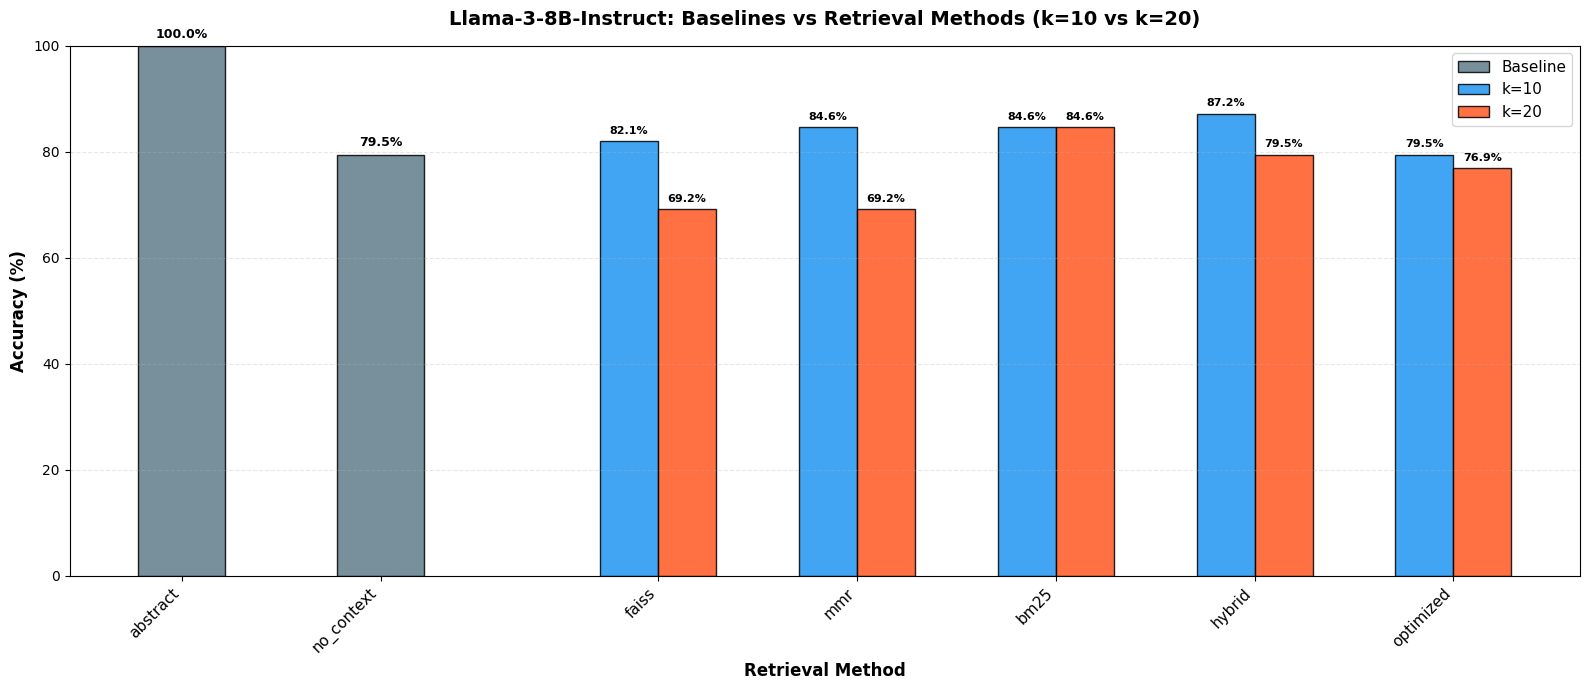

Combined bar chart generated


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# --- Collect all results ---
# Baselines (k-independent) from k=10 results
baseline_methods = ['abstract', 'no_context']
retrieval_methods = ['faiss', 'mmr', 'bm25', 'hybrid', 'optimized']

baseline_accs = {}
for m in baseline_methods:
    baseline_accs[m] = all_results[model_display_name]['k=10'][m]['accuracy']

k10_accs = {}
k20_accs = {}
for m in retrieval_methods:
    k10_accs[m] = all_results[model_display_name]['k=10'][m]['accuracy']
    k20_accs[m] = all_results[model_display_name]['k=20'][m]['accuracy']

# --- Print summary table ---
print("\n" + "="*90)
print("COMBINED RESULTS: Baselines + k=10 vs k=20")
print("="*90)
print(f"{'Method':<15} {'Baseline':<12} {'k=10':<12} {'k=20':<12} {'k10->k20':<12}")
print("-"*90)

for m in baseline_methods:
    print(f"{m:<15} {baseline_accs[m]:>6.2f}%      {'--':>6}       {'--':>6}       {'--':>6}")

for m in retrieval_methods:
    delta = k20_accs[m] - k10_accs[m]
    sign = '+' if delta >= 0 else ''
    print(f"{m:<15} {'--':>6}       {k10_accs[m]:>6.2f}%      {k20_accs[m]:>6.2f}%      {sign}{delta:.2f}%")

print("="*90)

# --- Combined grouped bar chart ---
# Layout: [abstract | no_context | faiss(k10,k20) | mmr(k10,k20) | bm25(k10,k20) | hybrid(k10,k20) | optimized(k10,k20)]
all_labels = baseline_methods + retrieval_methods
n_baselines = len(baseline_methods)
n_retrieval = len(retrieval_methods)

fig, ax = plt.subplots(figsize=(16, 7))

bar_width = 0.35
# X positions: baselines get single bars, retrieval methods get paired bars
x_positions = []
x_tick_positions = []
x_tick_labels = []
current_x = 0

# --- Baselines (single bars) ---
for i, m in enumerate(baseline_methods):
    ax.bar(current_x, baseline_accs[m], bar_width * 1.5, 
           color='#607D8B', alpha=0.85, edgecolor='black', label='Baseline' if i == 0 else None)
    # Value label
    ax.text(current_x, baseline_accs[m] + 1, f'{baseline_accs[m]:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=9)
    x_tick_positions.append(current_x)
    x_tick_labels.append(m)
    current_x += 1.2

# Add a small gap between baselines and retrieval methods
current_x += 0.3

# --- Retrieval methods (paired bars: k=10 and k=20) ---
for i, m in enumerate(retrieval_methods):
    x1 = current_x
    x2 = current_x + bar_width
    
    bar_k10 = ax.bar(x1, k10_accs[m], bar_width, color='#2196F3', alpha=0.85, 
                      edgecolor='black', label='k=10' if i == 0 else None)
    bar_k20 = ax.bar(x2, k20_accs[m], bar_width, color='#FF5722', alpha=0.85, 
                      edgecolor='black', label='k=20' if i == 0 else None)
    
    # Value labels
    ax.text(x1, k10_accs[m] + 1, f'{k10_accs[m]:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=8)
    ax.text(x2, k20_accs[m] + 1, f'{k20_accs[m]:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    x_tick_positions.append((x1 + x2) / 2)
    x_tick_labels.append(m)
    current_x += 1.2

ax.set_xlabel('Retrieval Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title(f'{model_display_name}: Baselines vs Retrieval Methods (k=10 vs k=20)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=11)
ax.legend(loc='upper right', frameon=True, fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("Combined bar chart generated")

In [25]:
# Export combined k=10 and k=20 results to CSV
combined_data = []

# Add baselines (marked as k=NA since they are k-independent)
for m in baseline_methods:
    r = all_results[model_display_name]['k=10'][m]
    combined_data.append({
        'model': model_display_name,
        'k': 'baseline',
        'method': m,
        'accuracy': r.get('accuracy', 0),
        'correct': r.get('correct_count', 0),
        'total': r.get('total', 0)
    })

# Add k=10 and k=20 retrieval results
for k_val in [10, 20]:
    for m in retrieval_methods:
        r = all_results[model_display_name][f'k={k_val}'][m]
        combined_data.append({
            'model': model_display_name,
            'k': k_val,
            'method': m,
            'accuracy': r.get('accuracy', 0),
            'correct': r.get('correct_count', 0),
            'total': r.get('total', 0)
        })

combined_df = pd.DataFrame(combined_data)
combined_csv = f'results_llama_k10_k20_combined_{timestamp}.csv'
combined_df.to_csv(combined_csv, index=False)
print("Combined results exported to CSV: " + combined_csv)
print(f"\nTotal rows: {len(combined_df)}")
print(combined_df.to_string(index=False))

Combined results exported to CSV: results_llama_k10_k20_combined_20260223_125640.csv

Total rows: 12
              model        k     method   accuracy  correct  total
Llama-3-8B-Instruct baseline   abstract 100.000000       39     39
Llama-3-8B-Instruct baseline no_context  79.487179       31     39
Llama-3-8B-Instruct       10      faiss  82.051282       32     39
Llama-3-8B-Instruct       10        mmr  84.615385       33     39
Llama-3-8B-Instruct       10       bm25  84.615385       33     39
Llama-3-8B-Instruct       10     hybrid  87.179487       34     39
Llama-3-8B-Instruct       10  optimized  79.487179       31     39
Llama-3-8B-Instruct       20      faiss  69.230769       27     39
Llama-3-8B-Instruct       20        mmr  69.230769       27     39
Llama-3-8B-Instruct       20       bm25  84.615385       33     39
Llama-3-8B-Instruct       20     hybrid  79.487179       31     39
Llama-3-8B-Instruct       20  optimized  76.923077       30     39


In [26]:
# Analyze cases where k=10 got correct but k=20 did not
retrieval_methods_to_check = ['faiss', 'mmr', 'bm25', 'hybrid', 'optimized']

print("="*100)
print("ERROR ANALYSIS: Questions where k=10 was CORRECT but k=20 was WRONG")
print("="*100)

total_regressions = 0

for method in retrieval_methods_to_check:
    k10_detailed = all_results[model_display_name]['k=10'][method]['detailed_results']
    k20_detailed = all_results[model_display_name]['k=20'][method]['detailed_results']
    
    regressions = []
    for i, (r10, r20) in enumerate(zip(k10_detailed, k20_detailed)):
        if r10.get('is_correct', False) and not r20.get('is_correct', False):
            regressions.append((i, r10, r20))
    
    if not regressions:
        print(f"\n{'='*100}")
        print(f"METHOD: {method.upper()} -- No regressions (k=10 correct -> k=20 wrong)")
        print(f"{'='*100}")
        continue
    
    total_regressions += len(regressions)
    
    print(f"\n{'='*100}")
    print(f"METHOD: {method.upper()} -- {len(regressions)} regression(s)")
    print(f"{'='*100}")
    
    for idx, r10, r20 in regressions:
        print(f"\n{'─'*90}")
        print(f"Question #{idx + 1}")
        print(f"{'─'*90}")
        
        # Query
        query = r10.get('query', 'N/A')
        print(f"\nQUESTION:\n{query}")
        
        # Correct answer
        print(f"\nCORRECT ANSWER: {r10.get('correct_answer', 'N/A')}")
        
        # k=10 response
        print(f"\n--- k=10 (CORRECT) ---")
        print(f"Model answer: {r10.get('model_answer', 'N/A')}")
        print(f"Response: {r10.get('full_response', 'N/A')[:500]}")
        
        # k=10 context (truncated)
        k10_ctx = r10.get('context', 'N/A')
        if k10_ctx and k10_ctx != 'N/A':
            print(f"\nk=10 Context (first 800 chars):\n{k10_ctx[:800]}...")
        
        # k=20 response
        print(f"\n--- k=20 (WRONG) ---")
        print(f"Model answer: {r20.get('model_answer', 'N/A')}")
        print(f"Response: {r20.get('full_response', 'N/A')[:500]}")
        
        # k=20 context (truncated)
        k20_ctx = r20.get('context', 'N/A')
        if k20_ctx and k20_ctx != 'N/A':
            print(f"\nk=20 Context (first 800 chars):\n{k20_ctx[:800]}...")

print(f"\n{'='*100}")
print(f"SUMMARY: {total_regressions} total regressions across all methods")
print(f"{'='*100}")

# Also show a compact summary table
print(f"\n{'Method':<15} {'k=10 Acc':<12} {'k=20 Acc':<12} {'Regressions':<15} {'Improvements':<15}")
print("-"*70)
for method in retrieval_methods_to_check:
    k10_detailed = all_results[model_display_name]['k=10'][method]['detailed_results']
    k20_detailed = all_results[model_display_name]['k=20'][method]['detailed_results']
    
    regressions = sum(1 for r10, r20 in zip(k10_detailed, k20_detailed) 
                      if r10.get('is_correct') and not r20.get('is_correct'))
    improvements = sum(1 for r10, r20 in zip(k10_detailed, k20_detailed) 
                       if not r10.get('is_correct') and r20.get('is_correct'))
    
    k10_acc = all_results[model_display_name]['k=10'][method]['accuracy']
    k20_acc = all_results[model_display_name]['k=20'][method]['accuracy']
    
    print(f"{method:<15} {k10_acc:>6.2f}%      {k20_acc:>6.2f}%      {regressions:<15} {improvements:<15}")

ERROR ANALYSIS: Questions where k=10 was CORRECT but k=20 was WRONG

METHOD: FAISS -- 6 regression(s)

──────────────────────────────────────────────────────────────────────────────────────────
Question #8
──────────────────────────────────────────────────────────────────────────────────────────

QUESTION:
What is the proposed mechanism by which urea affects the synthesis of thin-sheet HZSM-5 zeolites?
A) Urea increases the overall crystallization temperature.
B) Urea adsorbs on the (010) facet, influencing the b-axis thickness.
C) Urea acts as a catalyst in the hexane cracking reaction.
D) Urea changes the SiO2/Al2O3 ratio in the initial gel.
E) None of the above.

CORRECT ANSWER: B

--- k=10 (CORRECT) ---
Model answer: B
Response: <|begin_of_text|><|start_header_id|>user<|end_header_id|>

You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. You may use the provided context to inform your answer as well as your own knowledge. 

Provi